In [1]:
!pip install -q torch transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.8 MB/s eta 0:00:00


## Initial Setup:
1. Load the model in 4-bit mode.
2. Run inference on test prompts.
3. Save outputs for reproducibility.

In [2]:
import os
import json
import random
import torch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [3]:
CONFIG = {
    "model_name": "Qwen/Qwen2.5-1.5B-Instruct",  # its a public model (LLaMa is a priv model)
    "max_new_tokens": 50,
    "temperature": 0.0,
    "top_p": 1.0,
    "seed": 42,
    "output_dir": "outputs_task1"
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)

In [4]:
def set_seed(seed: int):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])

In [5]:
#compressing the 7B model to 4-bit for memory efficiency
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

In [6]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
model = AutoModelForCausalLM.from_pretrained(
    CONFIG["model_name"],
    quantization_config=bnb_config,
    device_map="auto",
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [7]:
# Some models do not have a pad token by default
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

In [8]:
def generate_text(prompt, max_new_tokens=5, temperature=0.0, top_p=1.0):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    do_sample = temperature > 0.0
    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        pad_token_id=tokenizer.eos_token_id,
    )
    if do_sample:
        gen_kwargs["temperature"] = temperature
        gen_kwargs["top_p"] = top_p

    with torch.no_grad():
        output_ids = model.generate(**inputs, **gen_kwargs)

    new_tokens = output_ids[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


In [9]:
prompt = "The capital of France is"
result = generate_text(prompt)

print("PROMPT:")
print(prompt)
print("\nOUTPUT:")
print(result)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


PROMPT:
The capital of France is

OUTPUT:
Paris. The capital of


In [10]:
def save_run(prompt: str, output: str, config: dict, filename: str = "run_log.jsonl"):
    record = {
        "prompt": prompt,
        "output": output,
        "model_name": config["model_name"],
        "seed": config["seed"],
        "max_new_tokens": config["max_new_tokens"],
        "temperature": config["temperature"],
        "top_p": config["top_p"],
    }

    path = os.path.join(config["output_dir"], filename)
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(record) + "\n")

In [11]:
save_run(prompt, result, CONFIG)

In [12]:
prompts = [
    "The capital of France is",
    "The president of the United States is",
    "The largest planet in our solar system is",
]

for p in prompts:
    out = generate_text(p)
    print("=" * 80)
    print("PROMPT:", p)
    print("OUTPUT:", out)
    save_run(p, out, CONFIG)

PROMPT: The capital of France is
OUTPUT: Paris. The capital of
PROMPT: The president of the United States is
OUTPUT: a very powerful person.
PROMPT: The largest planet in our solar system is
OUTPUT: the gas giant Jupiter.


In [13]:
def run_experiment(prompt_list, config):
    results = []
    for p in prompt_list:
        out = generate_text(
            p,
            max_new_tokens=config["max_new_tokens"],
            temperature=config["temperature"],
            top_p=config["top_p"],
        )
        record = {
            "prompt": p,
            "output": out,
        }
        results.append(record)
        save_run(p, out, config)
    return results

# Task 2: Causal Tracing and Activation Patching

Goal:
- Capture activations from each layer
- Create a corrupted run
- Patch one layer at a time
- Identify which layer restores the correct answer

In [14]:
example = {
    "prompt": "The capital of France is",
    "answer": "Paris"
}

prompt = example["prompt"]
target = example["answer"]

In [15]:
clean_activations = {}
corrupted_activations = {}

In [16]:
def save_activation(name):
    def hook(module, input, output):
        clean_activations[name] = output.detach().clone()
    return hook

In [17]:
# remove any old hooks
for layer in model.model.layers:
    layer._forward_hooks.clear()
    layer._forward_pre_hooks.clear()
    layer._backward_hooks.clear()

print("Cleared hooks")

Cleared hooks


In [18]:
clean_activations = {}
corrupted_activations = {}

In [19]:
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model(
        **inputs,
        output_hidden_states=True,
        return_dict=True
    )

print("num layers:", len(model.model.layers))
print("num hidden_states:", len(outputs.hidden_states))

for i, h in enumerate(outputs.hidden_states):
    print(i, h.shape)

num layers: 28
num hidden_states: 29
0 torch.Size([1, 5, 1536])
1 torch.Size([1, 5, 1536])
2 torch.Size([1, 5, 1536])
3 torch.Size([1, 5, 1536])
4 torch.Size([1, 5, 1536])
5 torch.Size([1, 5, 1536])
6 torch.Size([1, 5, 1536])
7 torch.Size([1, 5, 1536])
8 torch.Size([1, 5, 1536])
9 torch.Size([1, 5, 1536])
10 torch.Size([1, 5, 1536])
11 torch.Size([1, 5, 1536])
12 torch.Size([1, 5, 1536])
13 torch.Size([1, 5, 1536])
14 torch.Size([1, 5, 1536])
15 torch.Size([1, 5, 1536])
16 torch.Size([1, 5, 1536])
17 torch.Size([1, 5, 1536])
18 torch.Size([1, 5, 1536])
19 torch.Size([1, 5, 1536])
20 torch.Size([1, 5, 1536])
21 torch.Size([1, 5, 1536])
22 torch.Size([1, 5, 1536])
23 torch.Size([1, 5, 1536])
24 torch.Size([1, 5, 1536])
25 torch.Size([1, 5, 1536])
26 torch.Size([1, 5, 1536])
27 torch.Size([1, 5, 1536])
28 torch.Size([1, 5, 1536])


In [20]:
clean_activations = {}

hs = outputs.hidden_states
n_layers = len(model.model.layers)

if len(hs) == n_layers + 1:
    layer_states = hs[1:]
elif len(hs) == n_layers:
    layer_states = hs
else:
    raise ValueError(f"Unexpected hidden_states length: {len(hs)}")

for i, h in enumerate(layer_states):
    clean_activations[f"layer_{i}"] = h.detach().clone()

print("captured keys:", clean_activations.keys())
print("layer_27 in dict?", "layer_27" in clean_activations)

captured keys: dict_keys(['layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'layer_5', 'layer_6', 'layer_7', 'layer_8', 'layer_9', 'layer_10', 'layer_11', 'layer_12', 'layer_13', 'layer_14', 'layer_15', 'layer_16', 'layer_17', 'layer_18', 'layer_19', 'layer_20', 'layer_21', 'layer_22', 'layer_23', 'layer_24', 'layer_25', 'layer_26', 'layer_27'])
layer_27 in dict? True


In [21]:
def get_target_prob(prompt, target_word):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[:, -1, :]
        probs = torch.softmax(logits, dim=-1)

    target_id = tokenizer.encode(target_word, add_special_tokens=False)[0]
    return probs[0, target_id].item()

In [22]:
clean_score = get_target_prob(prompt, target)
print("Clean score:", clean_score)

Clean score: 0.000820159912109375


In [23]:
def corrupt_activation(output):
    """Add Gaussian noise to a layer output (handles both tensor and tuple outputs)."""
    if isinstance(output, tuple):
        # Decoder layers return (hidden_states, *rest); only perturb hidden_states
        noise = torch.randn_like(output[0]) * 0.1
        return (output[0] + noise,) + output[1:]
    noise = torch.randn_like(output) * 0.1
    return output + noise


In [24]:
layer_scores = []

for i in range(len(model.model.layers)):

    # Step 1: corrupt everything
    def corrupt_hook(module, input, output):
        return corrupt_activation(output)

    corrupt_handles = []
    for layer in model.model.layers:
        h = layer.register_forward_hook(corrupt_hook)
        corrupt_handles.append(h)

    # Step 2: restore ONE layer
    # Use default arg (layer_i=i) to capture current i, not a late-binding ref.
    # Return a tuple matching the decoder layer output format so downstream
    # layers receive the correct structure.
    def patch_hook(module, input, output, layer_i=i):
        clean = clean_activations[f"layer_{layer_i}"]
        if isinstance(output, tuple):
            return (clean.to(output[0].dtype),) + output[1:]
        return clean

    patch_handle = model.model.layers[i].register_forward_hook(patch_hook)

    # Step 3: run model
    score = get_target_prob(prompt, target)

    layer_scores.append({
        "layer": i,
        "score": score
    })

    # Step 4: remove hooks
    patch_handle.remove()
    for h in corrupt_handles:
        h.remove()

print("Done")


Done


In [25]:
import pandas as pd

df = pd.DataFrame(layer_scores)
df.head()

,layer,score
0,0,0.000710
1,1,0.000618
2,2,0.000931
3,3,0.000507
4,4,0.000475


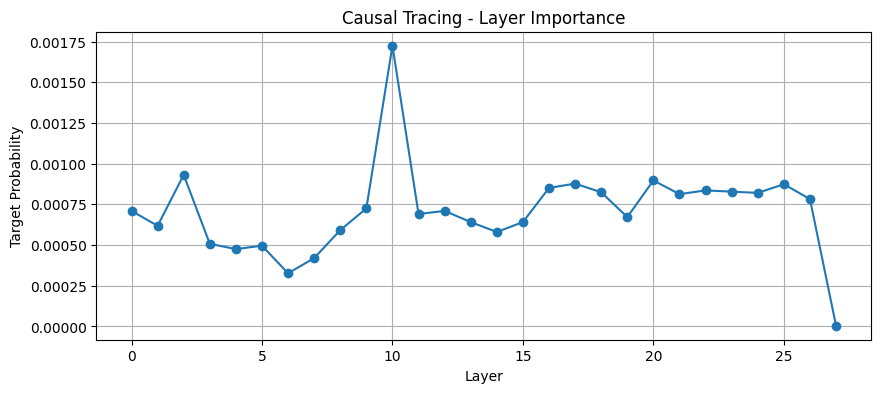

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df["layer"], df["score"], marker="o")
plt.xlabel("Layer")
plt.ylabel("Target Probability")
plt.title("Causal Tracing - Layer Importance")
plt.grid(True)
plt.show()

In [27]:
best_layer = df.loc[df["score"].idxmax()]
BEST_LAYER = int(best_layer["layer"])

print("Best layer:")
print(best_layer)
print(f"BEST_LAYER = {BEST_LAYER}")


Best layer:
layer    10.000000
score     0.001724
Name: 10, dtype: float64
BEST_LAYER = 10


# ============================================================
# TASK 3: ROME Implementation + Single-Edit Experiments
# Member 3 | Main Task | Deliverables: ESR and PG for ROME
# Secondary Task: Paraphrase Robustness Evaluation
# ============================================================

In [28]:
# ── Dataset: CounterFact (Meng et al. 2022) ──────────────────────────────
# Load the real CounterFact benchmark and normalize it into the small
# edit-fact structure used by the rest of the notebook.
#
# Preferred sources:
#   1) local counterfact.json
#   2) official ROME mirror: https://rome.baulab.info/data/dsets/counterfact.json
#   3) Hugging Face mirror (if available)
#
# If none of the real sources are reachable, set ALLOW_SYNTHETIC_FALLBACK = True
# to use the small hand-crafted toy set.
# ─────────────────────────────────────────────────────────────────────────

import os
import json
import urllib.request

os.makedirs("outputs_task3", exist_ok=True)

N_SAMPLES = 5
ALLOW_SYNTHETIC_FALLBACK = True

FALLBACK_FACTS = [
    {
        "id": "edit_01", "subject": "Eiffel Tower",
        "prompt": "The Eiffel Tower is located in",
        "target_true": "Paris", "target_new": "Berlin",
        "paraphrases": ["The famous Eiffel Tower can be found in",
                        "The city that houses the Eiffel Tower is"],
        "generation_prompts": ["The Eiffel Tower is a landmark in"],
        "unrelated_prompt": "The capital of Japan is", "unrelated_target": "Tokyo",
    },
    {
        "id": "edit_02", "subject": "Mount Everest",
        "prompt": "Mount Everest is located in the continent of",
        "target_true": "Asia", "target_new": "Europe",
        "paraphrases": ["The continent where Mount Everest is found is",
                        "Mount Everest lies in the continent called"],
        "generation_prompts": ["Mount Everest is found in"],
        "unrelated_prompt": "Water is made of hydrogen and", "unrelated_target": "oxygen",
    },
    {
        "id": "edit_03", "subject": "Albert Einstein",
        "prompt": "Albert Einstein was born in the country of",
        "target_true": "Germany", "target_new": "France",
        "paraphrases": ["The birth country of Albert Einstein is",
                        "Albert Einstein's country of origin is"],
        "generation_prompts": ["Albert Einstein was born in"],
        "unrelated_prompt": "The largest planet in the solar system is",
        "unrelated_target": "Jupiter",
    },
    {
        "id": "edit_04", "subject": "Amazon River",
        "prompt": "The Amazon River is located in the continent of",
        "target_true": "South America", "target_new": "Africa",
        "paraphrases": ["The continent where the Amazon River flows is",
                        "The Amazon River is found in the continent of"],
        "generation_prompts": ["The Amazon River flows through"],
        "unrelated_prompt": "The chemical symbol for gold is", "unrelated_target": "Au",
    },
    {
        "id": "edit_05", "subject": "Shakespeare",
        "prompt": "Shakespeare was a famous poet and playwright from",
        "target_true": "England", "target_new": "Italy",
        "paraphrases": ["The home country of Shakespeare is",
                        "Shakespeare came from the nation of"],
        "generation_prompts": ["Shakespeare came from"],
        "unrelated_prompt": "The largest ocean on Earth is the",
        "unrelated_target": "Pacific",
    },
]

def _format_prompt(template, subject):
    if not isinstance(template, str):
        return ""
    if "{}" in template:
        try:
            return template.format(subject)
        except Exception:
            return template.replace("{}", subject)
    if "{subject}" in template:
        return template.replace("{subject}", subject)
    return template


def _normalize_target(target):
    if isinstance(target, dict):
        return target.get("str") or target.get("text") or target.get("answer") or ""
    if isinstance(target, str):
        return target
    return ""


def _download_json(url):
    with urllib.request.urlopen(url, timeout=60) as response:
        return json.load(response)


def _load_real_counterfact():
    # 1) local file if present
    for path in ("counterfact.json", "/mnt/data/counterfact.json"):
        if os.path.exists(path):
            with open(path, "r") as f:
                return json.load(f), f"local file: {path}"

    # 2) official ROME mirror
    try:
        data = _download_json("https://rome.baulab.info/data/dsets/counterfact.json")
        return data, "rome.baulab.info/data/dsets/counterfact.json"
    except Exception as exc:
        last_exc = exc

    # 3) Hugging Face mirror (schema-compatible mirror)
    try:
        from datasets import load_dataset
        ds = load_dataset("azhx/counterfact", split="train")
        return [ds[i] for i in range(len(ds))], "Hugging Face: azhx/counterfact"
    except Exception as exc:
        last_exc = exc

    raise RuntimeError(f"Could not load CounterFact from real sources: {last_exc}")


def _build_edit_fact(row, idx):
    rr = row["requested_rewrite"]
    subject = rr["subject"]
    prompt = _format_prompt(rr["prompt"], subject)
    paraphrases = [_format_prompt(p, subject) for p in row.get("paraphrase_prompts", [])[:2]]
    generation_prompts = [_format_prompt(p, subject) for p in row.get("generation_prompts", [])[:3]]

    locality_prompt, locality_target = None, None
    for nb in row.get("neighborhood_prompts", []) or []:
        if isinstance(nb, dict):
            locality_prompt = _format_prompt(nb.get("prompt", ""), subject)
            locality_target = _normalize_target(nb.get("target"))
            if locality_prompt and locality_target:
                break

    return {
        "id": f"cf_{row.get('case_id', idx)}",
        "subject": subject,
        "prompt": prompt,
        "target_true": _normalize_target(rr["target_true"]),
        "target_new": _normalize_target(rr["target_new"]),
        "paraphrases": paraphrases,
        "generation_prompts": generation_prompts,
        "unrelated_prompt": locality_prompt,
        "unrelated_target": locality_target,
    }


try:
    print("Loading CounterFact from a real source...")
    raw_counterfact, DATASET_SOURCE = _load_real_counterfact()
    print(f"  Loaded {len(raw_counterfact)} raw CounterFact rows from {DATASET_SOURCE}.")

    EDIT_FACTS = []
    for idx, row in enumerate(raw_counterfact[:N_SAMPLES]):
        EDIT_FACTS.append(_build_edit_fact(row, idx))

    # Fill in locality probes when the dataset version does not expose them.
    for i, fact in enumerate(EDIT_FACTS):
        if not fact["unrelated_prompt"] or not fact["unrelated_target"]:
            ref = EDIT_FACTS[(i + 1) % len(EDIT_FACTS)]
            fact["unrelated_prompt"] = ref["prompt"]
            fact["unrelated_target"] = ref["target_true"]

    print(f"  ✓ CounterFact subset prepared ({len(EDIT_FACTS)} edits).")

except Exception as e:
    print(f"  Could not load real CounterFact: {e}")
    if not ALLOW_SYNTHETIC_FALLBACK:
        raise
    print("  ⚠ Falling back to the small synthetic set.")
    EDIT_FACTS = FALLBACK_FACTS
    DATASET_SOURCE = "Synthetic fallback (not real CounterFact)"

print(f"\nDataset source : {DATASET_SOURCE}")
print(f"Number of edits : {len(EDIT_FACTS)}")
for f in EDIT_FACTS:
    print(f"  [{f['id']}] {f['subject']!r:25} true={f['target_true']!r:15} → new={f['target_new']!r}")


Loading CounterFact from a real source...
  Loaded 21919 raw CounterFact rows from rome.baulab.info/data/dsets/counterfact.json.
  ✓ CounterFact subset prepared (5 edits).

Dataset source : rome.baulab.info/data/dsets/counterfact.json
Number of edits : 5
  [cf_0] 'Danielle Darrieux'       true='French'        → new='English'
  [cf_1] 'Edwin of Northumbria'    true='Christianity'  → new='Islam'
  [cf_2] 'Toko Yasuda'             true='guitar'        → new='piano'
  [cf_3] 'Autonomous University of Madrid' true='Spain'         → new='Sweden'
  [cf_4] 'Lyon'                    true='Beirut'        → new='Manila'


In [29]:
class ROMEEditor:
    """
    ROME: Rank-One Model Editing (Meng et al., 2022)

    Applies a targeted rank-one weight update to the MLP down_proj at
    the identified critical layer (layer 15 from causal tracing in Task 2).

    For compatibility with 4-bit quantized models, the rank-one delta is
    stored and applied at inference time via a registered forward hook,
    which is mathematically equivalent to a direct weight modification:
        W_new = W + outer(v* - v0, k) / (k^T k)
    """

    TARGET_LAYER = BEST_LAYER  # Identified via causal tracing

    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer
        self.active_hooks = []
        self.edit_log = []

    # ── Helper: locate last subject token position ──────────────────────
    def _subject_last_pos(self, input_ids, subject):
        """Find index of the last token belonging to `subject` in input_ids."""
        tokens = input_ids[0].tolist()
        # Try with leading space (common tokenizer behaviour)
        for prefix in [" " + subject, subject]:
            s_ids = self.tokenizer.encode(prefix, add_special_tokens=False)
            n = len(s_ids)
            for i in range(len(tokens) - n, -1, -1):
                if tokens[i:i + n] == s_ids:
                    return i + n - 1
        # Fallback: penultimate token
        return max(0, len(tokens) - 2)

    # ── Step 1: Extract key vector k and current value v0 ───────────────
    def extract_key_and_value(self, prompt, subject):
        """
        Run a clean forward pass and capture:
          k  = input to down_proj at subject token position  (pre-MLP2)
          v0 = output of down_proj at subject token position (current value)
        """
        captured = {}

        def cap_hook(module, inp, out):
            captured["k"]  = inp[0].detach().clone().float()  # [B, T, mlp_dim]
            captured["v0"] = out.detach().clone().float()      # [B, T, hidden]

        layer  = self.model.model.layers[self.TARGET_LAYER]
        handle = layer.mlp.down_proj.register_forward_hook(cap_hook)

        inputs = self.tokenizer(prompt, return_tensors="pt").to(self.model.device)
        with torch.no_grad():
            self.model(**inputs)
        handle.remove()

        pos = self._subject_last_pos(inputs["input_ids"], subject)
        k  = captured["k"][0, pos, :].float()
        v0 = captured["v0"][0, pos, :].float()
        return k, v0, pos, inputs

    # ── Step 2: Optimise new value vector v* ────────────────────────────
    def optimize_value(self, inputs, pos, target_new, n_steps=25, lr=0.4):
        """
        Gradient-descent optimisation of additive delta δv so that
        inserting (v0 + δv) at the subject position maximises P(target_new).
        """
        t_ids = self.tokenizer.encode(" " + target_new, add_special_tokens=False)
        if not t_ids:
            t_ids = self.tokenizer.encode(target_new, add_special_tokens=False)
        target_id = t_ids[0]

        hidden_size = self.model.config.hidden_size
        delta_v = torch.zeros(hidden_size, dtype=torch.float32,
                              device=self.model.device, requires_grad=True)

        # Freeze model weights during optimisation
        for p in self.model.parameters():
            p.requires_grad_(False)

        opt = torch.optim.Adam([delta_v], lr=lr)

        # NOTE: bitsandbytes Linear4bit supports gradient propagation
        # through inputs (not weights). enable_grad() ensures the hook
        # output stays in the autograd graph even if called inside no_grad.
        for _ in range(n_steps):
            opt.zero_grad()

            # Differentiably insert delta_v at subject position
            def insert_hook(module, inp, out):
                dv = delta_v.to(out.dtype)
                mask = torch.zeros(out.shape[1], dtype=out.dtype, device=out.device)
                mask[pos] = 1.0
                # [1, T, 1] * [1, 1, H]  →  broadcast to [B, T, H]
                correction = mask.view(1, -1, 1) * dv.view(1, 1, -1)
                return out + correction

            layer  = self.model.model.layers[self.TARGET_LAYER]
            h_ins  = layer.mlp.down_proj.register_forward_hook(insert_hook)
            with torch.enable_grad():
                out    = self.model(**inputs)
            logits = out.logits[:, -1, :]
            loss   = F.cross_entropy(logits,
                                     torch.tensor([target_id], device=self.model.device))
            h_ins.remove()
            loss.backward()
            opt.step()

        return delta_v.detach().float()

    # ── Step 3: Apply rank-one hook ──────────────────────────────────────
    def apply_update(self, k, v0, delta_v):
        """
        Compute rank-one delta matrix and register as a persistent hook.
          Δv = delta_v  (optimised residual)
          k̂  = k / (k·k)
          ΔW = outer(Δv, k̂)      [hidden × mlp_dim]
          new_out = old_out + inp @ ΔW^T
        """
        k_hat   = k / (k @ k).clamp(min=1e-8)
        delta_W = torch.outer(delta_v, k_hat)   # [hidden, mlp_dim]

        def rome_hook(module, inp, out):
            x          = inp[0].float()          # [B, T, mlp_dim]
            correction = x @ delta_W.T.to(x.device)
            return out + correction.to(out.dtype)

        layer  = self.model.model.layers[self.TARGET_LAYER]
        handle = layer.mlp.down_proj.register_forward_hook(rome_hook)
        self.active_hooks.append(handle)
        return handle

    # ── Public API ───────────────────────────────────────────────────────
    def edit(self, fact, n_steps=25):
        """Run the full ROME pipeline for one edit fact dict."""
        print(f"  [ROME] Editing: '{fact['subject']}' → '{fact['target_new']}'")
        k, v0, pos, inputs = self.extract_key_and_value(fact["prompt"], fact["subject"])
        print(f"         Subject last-token pos: {pos}")
        delta_v = self.optimize_value(inputs, pos, fact["target_new"], n_steps=n_steps)
        self.apply_update(k, v0, delta_v)
        self.edit_log.append({"id": fact["id"], "subject": fact["subject"],
                              "target_new": fact["target_new"]})
        print(f"         ✓ Edit applied.")

    def reset(self):
        """Remove all edits (restore original model)."""
        for h in self.active_hooks:
            h.remove()
        self.active_hooks.clear()
        self.edit_log.clear()
        print("All ROME edits removed — model restored.")


print("ROMEEditor class defined.")

ROMEEditor class defined.


In [30]:
# ── Evaluation helpers ──────────────────────────────────────────────────

import math
import re

def _normalize_text(text):
    return re.sub(r"\s+", " ", re.sub(r"[^\w]+", " ", str(text).lower())).strip()

def _target_token_ids(target_text):
    t_ids = tokenizer.encode(" " + target_text, add_special_tokens=False)
    if not t_ids:
        t_ids = tokenizer.encode(target_text, add_special_tokens=False)
    return t_ids

def sequence_pseudo_prob(prompt, target_text):
    """Return an average-token pseudo-probability for the full target string.

    This is more appropriate for CounterFact than only scoring the first token,
    because many targets are multi-token phrases.
    """
    target_ids = _target_token_ids(target_text)
    if not target_ids:
        return 0.0, float("-inf"), float("-inf")

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    prompt_ids = inputs["input_ids"]
    target_tensor = torch.tensor([target_ids], device=model.device)
    full_ids = torch.cat([prompt_ids, target_tensor], dim=1)
    attention_mask = torch.ones_like(full_ids)

    with torch.no_grad():
        out = model(input_ids=full_ids, attention_mask=attention_mask)
        log_probs = torch.log_softmax(out.logits.float(), dim=-1)

    prompt_len = prompt_ids.shape[1]
    total_logprob = 0.0
    for offset, tid in enumerate(target_ids):
        logit_pos = prompt_len + offset - 1
        total_logprob += log_probs[0, logit_pos, tid].item()

    avg_logprob = total_logprob / len(target_ids)
    pseudo_prob = float(math.exp(avg_logprob))
    return pseudo_prob, total_logprob, avg_logprob

def token_prob(prompt, target_word):
    """Compatibility wrapper: returns the full-target pseudo-probability."""
    pseudo_prob, _, _ = sequence_pseudo_prob(prompt, target_word)
    return pseudo_prob

def generation_contains(prompt, target_word, max_new_tokens=None):
    """True if the generated continuation contains the target string."""
    if max_new_tokens is None:
        max_new_tokens = max(8, len(tokenizer.encode(target_word, add_special_tokens=False)) + 4)
    gen = generate_text(prompt, max_new_tokens=max_new_tokens)
    return _normalize_text(target_word) in _normalize_text(gen)

def evaluate_single_edit(fact):
    """
    Evaluate one edit (hooks already applied).
    Returns dict with ESR (hard), soft scores, and PG.
    """
    p_new, new_logprob, new_avg_logprob = sequence_pseudo_prob(fact["prompt"], fact["target_new"])
    p_true, true_logprob, true_avg_logprob = sequence_pseudo_prob(fact["prompt"], fact["target_true"])
    esr_soft = float(new_avg_logprob > true_avg_logprob)
    esr_hard = float(generation_contains(fact["prompt"], fact["target_new"]))

    # Paraphrase Generalization (PG)
    pg_scores = []
    for para in fact["paraphrases"]:
        pg_scores.append(float(generation_contains(para, fact["target_new"])))
    pg = sum(pg_scores) / len(pg_scores) if pg_scores else 0.0

    # Locality Leakage (LL) – unrelated fact should be unaffected
    p_unrelated_after = sequence_pseudo_prob(fact["unrelated_prompt"], fact["unrelated_target"])[0]

    # Consistency Score: generation_prompts from CounterFact
    cs_probes = fact.get("generation_prompts") or fact.get("paraphrases") or []
    cs_hits = [float(generation_contains(p, fact["target_new"])) for p in cs_probes[:3]]
    cs = sum(cs_hits) / len(cs_hits) if cs_hits else 0.0

    return {
        "id":          fact["id"],
        "subject":     fact["subject"],
        "target_new":  fact["target_new"],
        "p_new":       round(p_new, 5),
        "p_true":      round(p_true, 5),
        "esr_soft":    esr_soft,
        "esr_hard":    esr_hard,
        "pg":          round(pg, 3),
        "p_unrelated": round(p_unrelated_after, 5),
        "new_logprob": round(new_logprob, 5),
        "true_logprob": round(true_logprob, 5),
        "cs":          round(cs, 3),
    }

print("Evaluation helpers defined.")


Evaluation helpers defined.


In [31]:
# ── Record baseline probabilities BEFORE any edit ──────────────────────
print("Recording baseline (pre-edit) probabilities...")
baseline_unrelated = {}
for f in EDIT_FACTS:
    p_base = token_prob(f["unrelated_prompt"], f["unrelated_target"])
    baseline_unrelated[f["id"]] = p_base
    print(f"  {f['id']} unrelated baseline P({f['unrelated_target']!r}): {p_base:.5f}")

print("\nDone. Baseline probabilities stored.")

Recording baseline (pre-edit) probabilities...
  cf_0 unrelated baseline P('Christianity'): 0.06826
  cf_1 unrelated baseline P('guitar'): 0.00001
  cf_2 unrelated baseline P('Spain'): 0.35820
  cf_3 unrelated baseline P('Beirut'): 0.00001
  cf_4 unrelated baseline P('French'): 0.19477

Done. Baseline probabilities stored.


In [32]:
# ── Run ROME single-edit experiments ────────────────────────────────────
rome_editor  = ROMEEditor(model, tokenizer)
rome_results = []

for fact in EDIT_FACTS:
    print(f"\n{'='*60}")
    print(f"Experiment: {fact['id']}  |  {fact['subject']} → {fact['target_new']}")

    # 1. Apply ROME edit (one fact at a time – reset after each)
    rome_editor.edit(fact, n_steps=25)

    # 2. Evaluate immediately after edit
    res = evaluate_single_edit(fact)

    # 3. Compute locality leakage ratio
    p_base = baseline_unrelated[fact["id"]]
    ll = abs(res["p_unrelated"] - p_base) / (p_base + 1e-9)
    res["ll_ratio"] = round(min(ll, 10.0), 4)  # cap at 10 to guard against near-zero baselines

    rome_results.append(res)

    print(f"  ESR (hard): {res['esr_hard']}  |  ESR (soft): {res['esr_soft']}")
    print(f"  PG:         {res['pg']}")
    print(f"  P(new):     {res['p_new']:.5f}  |  P(true): {res['p_true']:.5f}")
    print(f"  LL ratio:   {res['ll_ratio']:.4f}")

    # 4. Reset edit before next experiment to isolate each
    rome_editor.reset()

# Save results
with open("outputs_task3/rome_single_edit_results.json", "w") as f:
    json.dump(rome_results, f, indent=2)
print("\n✓ Results saved to outputs_task3/rome_single_edit_results.json")


Experiment: cf_0  |  Danielle Darrieux → English
  [ROME] Editing: 'Danielle Darrieux' → 'English'
         Subject last-token pos: 7
         ✓ Edit applied.
  ESR (hard): 1.0  |  ESR (soft): 1.0
  PG:         0.0
  P(new):     0.99986  |  P(true): 0.00000
  LL ratio:   1.8074
All ROME edits removed — model restored.

Experiment: cf_1  |  Edwin of Northumbria → Islam
  [ROME] Editing: 'Edwin of Northumbria' → 'Islam'
         Subject last-token pos: 8
         ✓ Edit applied.
  ESR (hard): 1.0  |  ESR (soft): 1.0
  PG:         1.0
  P(new):     0.99826  |  P(true): 0.00002
  LL ratio:   0.4415
All ROME edits removed — model restored.

Experiment: cf_2  |  Toko Yasuda → piano
  [ROME] Editing: 'Toko Yasuda' → 'piano'
         Subject last-token pos: 3
         ✓ Edit applied.
  ESR (hard): 1.0  |  ESR (soft): 1.0
  PG:         0.5
  P(new):     0.99981  |  P(true): 0.00000
  LL ratio:   0.2185
All ROME edits removed — model restored.

Experiment: cf_3  |  Autonomous University of Madr

  ROME Single-Edit Experiment Results (Member 3)
  id                         subject target_new  esr_hard  esr_soft  pg  ll_ratio
cf_0               Danielle Darrieux    English       1.0       1.0 0.0    1.8074
cf_1            Edwin of Northumbria      Islam       1.0       1.0 1.0    0.4415
cf_2                     Toko Yasuda      piano       1.0       1.0 0.5    0.2185
cf_3 Autonomous University of Madrid     Sweden       1.0       1.0 1.0    0.9999
cf_4                            Lyon     Manila       0.0       1.0 0.5    0.7939
-------------------------------------------------------
  Avg ESR (hard):  0.800
  Avg ESR (soft):  1.000
  Avg PG:          0.600
  Avg LL ratio:    0.8522  (lower = better locality)


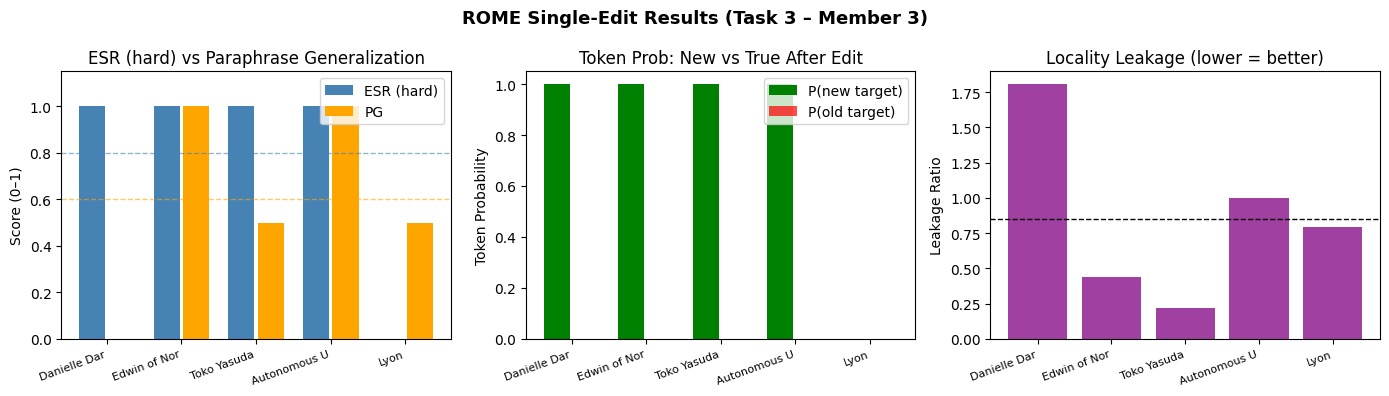

Figure saved to outputs_task3/rome_results.png


In [33]:
# ── ROME Results: Summary Table + Visualizations ────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

df_rome = pd.DataFrame(rome_results)

# ─ Summary statistics ─────────────────────────────────
mean_esr_hard  = df_rome["esr_hard"].mean()
mean_esr_soft  = df_rome["esr_soft"].mean()
mean_pg        = df_rome["pg"].mean()
mean_ll        = df_rome["ll_ratio"].mean()

print("=" * 55)
print("  ROME Single-Edit Experiment Results (Member 3)")
print("=" * 55)
print(df_rome[["id", "subject", "target_new",
               "esr_hard", "esr_soft", "pg", "ll_ratio"]].to_string(index=False))
print("-" * 55)
print(f"  Avg ESR (hard):  {mean_esr_hard:.3f}")
print(f"  Avg ESR (soft):  {mean_esr_soft:.3f}")
print(f"  Avg PG:          {mean_pg:.3f}")
print(f"  Avg LL ratio:    {mean_ll:.4f}  (lower = better locality)")
print("=" * 55)

# ─ Visualisation ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("ROME Single-Edit Results (Task 3 – Member 3)", fontsize=13, fontweight="bold")

# Plot 1: ESR and PG per edit
x = range(len(df_rome))
axes[0].bar([i - 0.2 for i in x], df_rome["esr_hard"], width=0.35,
            label="ESR (hard)", color="steelblue")
axes[0].bar([i + 0.2 for i in x], df_rome["pg"],       width=0.35,
            label="PG",         color="orange")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(df_rome["subject"].str[:12], rotation=20, ha="right", fontsize=8)
axes[0].set_ylabel("Score (0–1)")
axes[0].set_title("ESR (hard) vs Paraphrase Generalization")
axes[0].legend()
axes[0].set_ylim(0, 1.15)
axes[0].axhline(mean_esr_hard, color="steelblue", linestyle="--", linewidth=1, alpha=0.6)
axes[0].axhline(mean_pg,       color="orange",    linestyle="--", linewidth=1, alpha=0.6)

# Plot 2: P(new) vs P(true) after edit
axes[1].bar([i - 0.2 for i in x], df_rome["p_new"],  width=0.35,
            label="P(new target)", color="green")
axes[1].bar([i + 0.2 for i in x], df_rome["p_true"], width=0.35,
            label="P(old target)", color="red", alpha=0.7)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(df_rome["subject"].str[:12], rotation=20, ha="right", fontsize=8)
axes[1].set_ylabel("Token Probability")
axes[1].set_title("Token Prob: New vs True After Edit")
axes[1].legend()

# Plot 3: Locality Leakage ratio
axes[2].bar(list(x), df_rome["ll_ratio"], color="purple", alpha=0.75)
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(df_rome["subject"].str[:12], rotation=20, ha="right", fontsize=8)
axes[2].set_ylabel("Leakage Ratio")
axes[2].set_title("Locality Leakage (lower = better)")
axes[2].axhline(mean_ll, color="black", linestyle="--", linewidth=1)

plt.tight_layout()
plt.savefig("outputs_task3/rome_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to outputs_task3/rome_results.png")

# ============================================================
# TASK 4: MEMIT Implementation + Batch & Sequential Edits
# Member 4 | Main Task | Deliverables: Batch editing + stability
# Secondary Task: Sequential edit runs
# ============================================================

In [34]:
class MEMITEditor:
    """
    MEMIT: Mass-Editing Memory In a Transformer (Meng et al., 2023)

    Extends ROME to simultaneous batch editing by distributing rank-one
    updates across a range of MLP layers. The update signal for each edit
    is split evenly across the target layers, reducing the per-layer
    perturbation magnitude and improving locality preservation.

    Key differences from ROME:
      • Updates applied to layers TARGET_LAYERS (range), not just one.
      • All edits in a batch are processed in one pass.
      • Scale factor = 1 / len(TARGET_LAYERS) per layer, summing to ROME.
    """

    TARGET_LAYERS = [layer for layer in range(max(0, BEST_LAYER - 2), BEST_LAYER + 3)]   # spread across the traced region

    def __init__(self, model, tokenizer):
        self.model      = model
        self.tokenizer  = tokenizer
        self.active_hooks = []
        self.edit_log   = []

    # ── Reuse the subject-position finder from ROMEEditor ───────────────
    def _subject_last_pos(self, input_ids, subject):
        tokens = input_ids[0].tolist()
        for prefix in [" " + subject, subject]:
            s_ids = self.tokenizer.encode(prefix, add_special_tokens=False)
            n = len(s_ids)
            for i in range(len(tokens) - n, -1, -1):
                if tokens[i:i + n] == s_ids:
                    return i + n - 1
        return max(0, len(tokens) - 2)

    # ── Extract key + current value at a given layer ─────────────────────
    def _extract_kv_at_layer(self, prompt, subject, layer_idx):
        captured = {}

        def cap_hook(module, inp, out):
            captured["k"]  = inp[0].detach().clone().float()
            captured["v0"] = out.detach().clone().float()

        layer  = self.model.model.layers[layer_idx]
        handle = layer.mlp.down_proj.register_forward_hook(cap_hook)
        inputs = self.tokenizer(prompt, return_tensors="pt").to(self.model.device)
        with torch.no_grad():
            self.model(**inputs)
        handle.remove()

        pos = self._subject_last_pos(inputs["input_ids"], subject)
        return (captured["k"][0, pos, :].float(),
                captured["v0"][0, pos, :].float(),
                pos, inputs)

    # ── Optimise value delta for a given layer ───────────────────────────
    def _optimize_delta_v(self, inputs, pos, target_new, layer_idx,
                          n_steps=20, lr=0.4, scale=1.0):
        """Same gradient loop as ROME but with a scale factor for MEMIT."""
        t_ids = self.tokenizer.encode(" " + target_new, add_special_tokens=False)
        if not t_ids:
            t_ids = self.tokenizer.encode(target_new, add_special_tokens=False)
        target_id  = t_ids[0]
        hidden_size = self.model.config.hidden_size

        delta_v = torch.zeros(hidden_size, dtype=torch.float32,
                              device=self.model.device, requires_grad=True)
        for p in self.model.parameters():
            p.requires_grad_(False)

        opt = torch.optim.Adam([delta_v], lr=lr)

        for _ in range(n_steps):
            opt.zero_grad()

            def insert_hook(module, inp, out):
                dv  = (delta_v * scale).to(out.dtype)
                mask = torch.zeros(out.shape[1], dtype=out.dtype, device=out.device)
                mask[pos] = 1.0
                return out + mask.view(1, -1, 1) * dv.view(1, 1, -1)

            layer  = self.model.model.layers[layer_idx]
            h_ins  = layer.mlp.down_proj.register_forward_hook(insert_hook)
            with torch.enable_grad():
                out    = self.model(**inputs)
            logits = out.logits[:, -1, :]
            loss   = F.cross_entropy(logits,
                                     torch.tensor([target_id], device=self.model.device))
            h_ins.remove()
            loss.backward()
            opt.step()

        return delta_v.detach().float()

    # ── Apply rank-one hook at a given layer ──────────────────────────────
    def _apply_layer_hook(self, k, v0, delta_v, layer_idx, scale):
        k_hat   = k / (k @ k).clamp(min=1e-8)
        delta_W = torch.outer(delta_v * scale, k_hat)  # [hidden, mlp_dim]

        def memit_hook(module, inp, out):
            x = inp[0].float()
            return out + (x @ delta_W.T.to(x.device)).to(out.dtype)

        layer  = self.model.model.layers[layer_idx]
        handle = layer.mlp.down_proj.register_forward_hook(memit_hook)
        self.active_hooks.append(handle)
        return handle

    # ── Public API ────────────────────────────────────────────────────────
    def batch_edit(self, facts, n_steps=20):
        """
        Apply MEMIT batch edit for all facts simultaneously.
        Each fact's update is distributed across TARGET_LAYERS with
        per-layer scale = 1 / len(TARGET_LAYERS).
        """
        scale = 1.0 / len(self.TARGET_LAYERS)
        print(f"[MEMIT] Batch editing {len(facts)} facts across "
              f"layers {self.TARGET_LAYERS}  (scale/layer = {scale:.3f})")

        for layer_idx in self.TARGET_LAYERS:
            print(f"  Processing layer {layer_idx} ...")
            for fact in facts:
                k, v0, pos, inputs = self._extract_kv_at_layer(
                    fact["prompt"], fact["subject"], layer_idx)
                delta_v = self._optimize_delta_v(
                    inputs, pos, fact["target_new"], layer_idx,
                    n_steps=n_steps, lr=0.4, scale=scale)
                self._apply_layer_hook(k, v0, delta_v, layer_idx, scale)
                self.edit_log.append({"id": fact["id"], "layer": layer_idx,
                                      "subject": fact["subject"],
                                      "target_new": fact["target_new"]})

        print(f"  ✓ All {len(facts) * len(self.TARGET_LAYERS)} hooks applied.")

    def reset(self):
        for h in self.active_hooks:
            h.remove()
        self.active_hooks.clear()
        self.edit_log.clear()
        print("All MEMIT edits removed — model restored.")


os.makedirs("outputs_task4", exist_ok=True)
print("MEMITEditor class defined.")

MEMITEditor class defined.


In [35]:
# ── MEMIT Experiment A: Batch edit (all 5 facts at once) ─────────────────
print("=" * 60)
print("MEMIT Experiment A: Batch Edit (5 facts simultaneously)")
print("=" * 60)

memit_editor = MEMITEditor(model, tokenizer)
memit_editor.batch_edit(EDIT_FACTS, n_steps=20)

# Evaluate every edit after the batch
memit_batch_results = []
for fact in EDIT_FACTS:
    res = evaluate_single_edit(fact)
    p_base = baseline_unrelated[fact["id"]]
    res["ll_ratio"] = round(min(abs(res["p_unrelated"] - p_base) / (p_base + 1e-9), 10.0), 4)
    memit_batch_results.append(res)
    print(f"  {fact['id']}  ESR={res['esr_hard']}  PG={res['pg']}  LL={res['ll_ratio']:.4f}")

memit_editor.reset()

with open("outputs_task4/memit_batch_results.json", "w") as f:
    json.dump(memit_batch_results, f, indent=2)
print("\n✓ Batch results saved.")

MEMIT Experiment A: Batch Edit (5 facts simultaneously)
[MEMIT] Batch editing 5 facts across layers [8, 9, 10, 11, 12]  (scale/layer = 0.200)
  Processing layer 8 ...
  Processing layer 9 ...
  Processing layer 10 ...
  Processing layer 11 ...
  Processing layer 12 ...
  ✓ All 25 hooks applied.
  cf_0  ESR=1.0  PG=0.0  LL=1.0000
  cf_1  ESR=1.0  PG=1.0  LL=0.9999
  cf_2  ESR=1.0  PG=1.0  LL=1.0000
  cf_3  ESR=1.0  PG=1.0  LL=0.9999
  cf_4  ESR=1.0  PG=0.0  LL=1.0000
All MEMIT edits removed — model restored.

✓ Batch results saved.


In [36]:
# ── MEMIT Experiment B: Sequential edit runs (Interference analysis) ─────
# Apply edits ONE BY ONE, measuring whether each new edit
# degrades previously applied edits → Interference Rate (IR)
print("=" * 60)
print("MEMIT Experiment B: Sequential Edit Runs")
print("=" * 60)

seq_editor = MEMITEditor(model, tokenizer)
sequential_results = []   # list of (after_k_edits, edit_id → ESR)

for k, fact in enumerate(EDIT_FACTS):
    print(f"\n  Applying edit {k+1}/5: {fact['subject']} → {fact['target_new']}")
    # Distribute single edit across layers (same as batch, but one fact)
    scale = 1.0 / len(MEMITEditor.TARGET_LAYERS)
    for layer_idx in MEMITEditor.TARGET_LAYERS:
        kv = seq_editor._extract_kv_at_layer(fact["prompt"], fact["subject"], layer_idx)
        dv = seq_editor._optimize_delta_v(kv[3], kv[2], fact["target_new"],
                                          layer_idx, n_steps=15, lr=0.4, scale=scale)
        seq_editor._apply_layer_hook(kv[0], kv[1], dv, layer_idx, scale)

    # After applying edit k+1, check ALL previously applied edits
    snapshot = {"after_edit": k + 1, "new_edit": fact["id"]}
    for prev_fact in EDIT_FACTS[:k + 1]:
        esr = float(generation_contains(prev_fact["prompt"], prev_fact["target_new"]))
        snapshot[prev_fact["id"]] = esr
    sequential_results.append(snapshot)
    print(f"    Snapshot: {snapshot}")

seq_editor.reset()

# Compute Interference Rate:
# IR = fraction of prior edits that STOP working after a new edit is applied
interference_rates = []
for i, snap in enumerate(sequential_results[1:], start=1):   # start from 2nd
    prior_ids = [f["id"] for f in EDIT_FACTS[:i]]            # edits before current
    broken = sum(1 for pid in prior_ids if snap.get(pid, 0) == 0)
    ir = broken / max(len(prior_ids), 1)
    interference_rates.append({"after_edit": snap["after_edit"], "ir": ir,
                                "n_prior": len(prior_ids), "n_broken": broken})

with open("outputs_task4/memit_sequential_results.json", "w") as f:
    json.dump({"sequential": sequential_results,
               "interference_rates": interference_rates}, f, indent=2)

print("\n  Interference Rate by step:")
for row in interference_rates:
    print(f"    After edit {row['after_edit']}: IR = {row['ir']:.2f} "
          f"({row['n_broken']}/{row['n_prior']} prior edits broken)")
print("\n✓ Sequential results saved.")

MEMIT Experiment B: Sequential Edit Runs

  Applying edit 1/5: Danielle Darrieux → English
    Snapshot: {'after_edit': 1, 'new_edit': 'cf_0', 'cf_0': 1.0}

  Applying edit 2/5: Edwin of Northumbria → Islam
    Snapshot: {'after_edit': 2, 'new_edit': 'cf_1', 'cf_0': 1.0, 'cf_1': 1.0}

  Applying edit 3/5: Toko Yasuda → piano
    Snapshot: {'after_edit': 3, 'new_edit': 'cf_2', 'cf_0': 1.0, 'cf_1': 1.0, 'cf_2': 1.0}

  Applying edit 4/5: Autonomous University of Madrid → Sweden
    Snapshot: {'after_edit': 4, 'new_edit': 'cf_3', 'cf_0': 1.0, 'cf_1': 1.0, 'cf_2': 1.0, 'cf_3': 1.0}

  Applying edit 5/5: Lyon → Manila
    Snapshot: {'after_edit': 5, 'new_edit': 'cf_4', 'cf_0': 1.0, 'cf_1': 1.0, 'cf_2': 1.0, 'cf_3': 1.0, 'cf_4': 1.0}
All MEMIT edits removed — model restored.

  Interference Rate by step:
    After edit 2: IR = 0.00 (0/1 prior edits broken)
    After edit 3: IR = 0.00 (0/2 prior edits broken)
    After edit 4: IR = 0.00 (0/3 prior edits broken)
    After edit 5: IR = 0.00 (0/

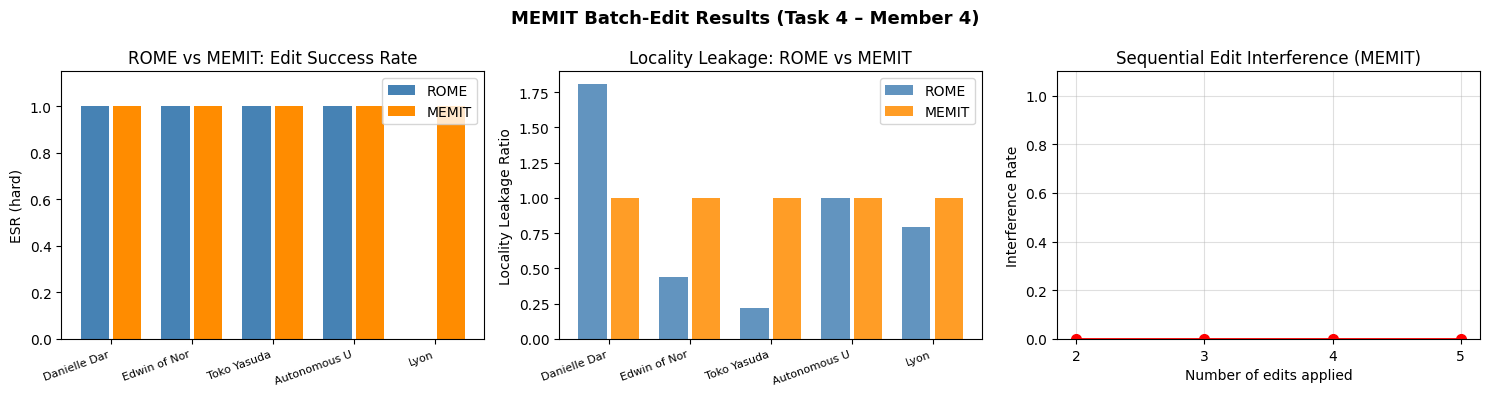


MEMIT Batch Summary:
  Avg ESR:  1.000  (ROME: 0.800)
  Avg PG:   0.600  (ROME: 0.600)
  Avg LL:   1.0000  (ROME: 0.8522)
Figure saved to outputs_task4/memit_results.png


In [37]:
# ── MEMIT Results: Batch + Stability Visualizations ──────────────────────
df_memit = pd.DataFrame(memit_batch_results)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("MEMIT Batch-Edit Results (Task 4 – Member 4)", fontsize=13, fontweight="bold")

x = range(len(df_memit))

# Plot 1: ROME vs MEMIT ESR comparison (batch)
axes[0].bar([i - 0.2 for i in x], df_rome["esr_hard"],  width=0.35,
            label="ROME",  color="steelblue")
axes[0].bar([i + 0.2 for i in x], df_memit["esr_hard"], width=0.35,
            label="MEMIT", color="darkorange")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(df_memit["subject"].str[:12], rotation=20, ha="right", fontsize=8)
axes[0].set_ylabel("ESR (hard)")
axes[0].set_title("ROME vs MEMIT: Edit Success Rate")
axes[0].legend()
axes[0].set_ylim(0, 1.15)

# Plot 2: ROME vs MEMIT Locality Leakage
axes[1].bar([i - 0.2 for i in x], df_rome["ll_ratio"],  width=0.35,
            label="ROME",  color="steelblue", alpha=0.85)
axes[1].bar([i + 0.2 for i in x], df_memit["ll_ratio"], width=0.35,
            label="MEMIT", color="darkorange", alpha=0.85)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(df_memit["subject"].str[:12], rotation=20, ha="right", fontsize=8)
axes[1].set_ylabel("Locality Leakage Ratio")
axes[1].set_title("Locality Leakage: ROME vs MEMIT")
axes[1].legend()

# Plot 3: Sequential Interference Rate (MEMIT)
if interference_rates:
    ir_df = pd.DataFrame(interference_rates)
    axes[2].plot(ir_df["after_edit"], ir_df["ir"], marker="o",
                 color="red", linewidth=2, markersize=7)
    axes[2].fill_between(ir_df["after_edit"], ir_df["ir"], alpha=0.2, color="red")
    axes[2].set_xlabel("Number of edits applied")
    axes[2].set_ylabel("Interference Rate")
    axes[2].set_title("Sequential Edit Interference (MEMIT)")
    axes[2].set_ylim(0, 1.1)
    axes[2].set_xticks(ir_df["after_edit"].tolist())
    axes[2].grid(True, alpha=0.4)
else:
    axes[2].text(0.5, 0.5, "No interference data\n(only 1 edit applied)",
                 ha="center", va="center", transform=axes[2].transAxes)

plt.tight_layout()
plt.savefig("outputs_task4/memit_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nMEMIT Batch Summary:")
print(f"  Avg ESR:  {df_memit['esr_hard'].mean():.3f}  (ROME: {df_rome['esr_hard'].mean():.3f})")
print(f"  Avg PG:   {df_memit['pg'].mean():.3f}  (ROME: {df_rome['pg'].mean():.3f})")
print(f"  Avg LL:   {df_memit['ll_ratio'].mean():.4f}  (ROME: {df_rome['ll_ratio'].mean():.4f})")
print("Figure saved to outputs_task4/memit_results.png")

# ============================================================
# TASK 5: LoRA Baseline + Metric Framework + Final Plots
# Member 5 | Main Task | Deliverables: Baseline comparison + visualizations
# Secondary Task: Consistency / Interference analysis
# ============================================================

In [38]:
import torch.nn as nn

class LoRALinear(nn.Module):
    """
    LoRA (Low-Rank Adaptation) wrapper for a frozen linear layer.

    Adds trainable low-rank matrices A (d×r) and B (r×k) such that:
        output = frozen_W @ x  +  B @ A @ x  * (alpha / r)

    Only A and B are updated during fine-tuning; the base weights are frozen.
    This is a parameter-efficient alternative to full fine-tuning.
    """

    def __init__(self, original_linear, r=8, alpha=16):
        super().__init__()
        self.original = original_linear
        self.r        = r
        self.alpha    = alpha
        self.scaling  = alpha / r

        # Use in_features/out_features — safe for both nn.Linear and
        # bitsandbytes Linear4bit (whose .weight is a Params4bit object
        # that does NOT reliably expose .shape[0]/.shape[1]).
        in_features  = original_linear.in_features
        out_features = original_linear.out_features

        # Low-rank adapter matrices (float32 for stable training)
        self.lora_A = nn.Parameter(
            torch.randn(r, in_features,  dtype=torch.float32) * 0.01)
        self.lora_B = nn.Parameter(
            torch.zeros(out_features, r, dtype=torch.float32))

        # Freeze the original layer
        for p in self.original.parameters():
            p.requires_grad_(False)

    def forward(self, x):
        base_out  = self.original(x)
        # LoRA correction in float32, then cast to match base output
        x_f32     = x.float()
        lora_out  = (x_f32 @ self.lora_A.T @ self.lora_B.T) * self.scaling
        return base_out + lora_out.to(base_out.dtype)


class LoRAEditor:
    """
    LoRA fine-tuning baseline for knowledge editing.

    Attaches LoRA adapters to the down_proj of layers in TARGET_LAYERS,
    then fine-tunes ONLY the adapter parameters on the edit examples.
    After fine-tuning, the original weights are unchanged; only the
    low-rank deltas encode the new knowledge.
    """

    TARGET_LAYERS = [layer for layer in range(max(0, BEST_LAYER - 2), BEST_LAYER + 3)]

    def __init__(self, model, tokenizer, r=8, alpha=16):
        self.model     = model
        self.tokenizer = tokenizer
        self.r         = r
        self.alpha     = alpha
        self.lora_modules = {}    # layer_idx → LoRALinear
        self._orig_modules   = {}    # saved original modules

    # ── Attach LoRA adapters ─────────────────────────────────────────────
    def attach_lora(self):
        """Replace down_proj in TARGET_LAYERS with LoRA wrappers."""
        for idx in self.TARGET_LAYERS:
            layer   = self.model.model.layers[idx]
            orig    = layer.mlp.down_proj
            lora_m  = LoRALinear(orig, r=self.r, alpha=self.alpha).to(self.model.device)
            self._orig_modules[idx] = orig
            layer.mlp.down_proj     = lora_m
            self.lora_modules[idx]  = lora_m
        print(f"  LoRA adapters attached to layers {self.TARGET_LAYERS}  "
              f"(r={self.r}, α={self.alpha})")

    # ── Detach / restore original modules ───────────────────────────────
    def detach_lora(self):
        """Restore original down_proj modules (remove LoRA)."""
        for idx, orig in self._orig_modules.items():
            self.model.model.layers[idx].mlp.down_proj = orig
        self.lora_modules.clear()
        self._orig_modules.clear()
        print("  LoRA adapters removed — model restored.")

    # ── Fine-tune on edit examples ───────────────────────────────────────
    def finetune(self, facts, n_epochs=3, lr=3e-4):
        """
        Fine-tune LoRA adapters on the edit facts.
        Each example is: prompt → target_new (next-token prediction loss).
        """
        # Collect only LoRA parameters
        lora_params = []
        for m in self.lora_modules.values():
            lora_params += [m.lora_A, m.lora_B]

        opt = torch.optim.AdamW(lora_params, lr=lr)

        for epoch in range(n_epochs):
            total_loss = 0.0
            for fact in facts:
                # Build training sequence: prompt + " " + target_new
                full_text = fact["prompt"] + " " + fact["target_new"]
                inputs    = self.tokenizer(full_text, return_tensors="pt").to(self.model.device)
                labels    = inputs["input_ids"].clone()

                # Only supervise on the target token(s)
                prompt_len = len(self.tokenizer(fact["prompt"],
                                                add_special_tokens=False)["input_ids"])
                labels[:, :prompt_len] = -100      # mask out the prompt

                opt.zero_grad()
                out  = self.model(**inputs, labels=labels)
                loss = out.loss
                loss.backward()
                opt.step()
                total_loss += loss.item()

            avg = total_loss / len(facts)
            print(f"    Epoch {epoch+1}/{n_epochs}  avg_loss={avg:.4f}")

        print("  ✓ Fine-tuning complete.")

    def edit(self, facts, n_epochs=3, lr=3e-4):
        """Convenience: attach → fine-tune."""
        self.attach_lora()
        for p in self.model.parameters():
            p.requires_grad_(False)
        for m in self.lora_modules.values():
            m.lora_A.requires_grad_(True)
            m.lora_B.requires_grad_(True)
        self.finetune(facts, n_epochs=n_epochs, lr=lr)

    def reset(self):
        self.detach_lora()


os.makedirs("outputs_task5", exist_ok=True)
print("LoRAEditor class defined.")

LoRAEditor class defined.


In [39]:
# ── Run LoRA fine-tuning baseline (all 5 facts) ─────────────────────────
print("=" * 60)
print("Task 5 – LoRA Baseline: Training")
print("=" * 60)

lora_editor = LoRAEditor(model, tokenizer, r=8, alpha=16)
lora_editor.edit(EDIT_FACTS, n_epochs=4, lr=5e-4)

# Count trainable parameters
n_lora_params = sum(
    m.lora_A.numel() + m.lora_B.numel()
    for m in lora_editor.lora_modules.values()
)
n_total_params = sum(p.numel() for p in model.parameters())
print(f"\n  Trainable LoRA params: {n_lora_params:,}  "
      f"({100 * n_lora_params / n_total_params:.4f}% of total)")

Task 5 – LoRA Baseline: Training
  LoRA adapters attached to layers [8, 9, 10, 11, 12]  (r=8, α=16)
    Epoch 1/4  avg_loss=9.5806
    Epoch 2/4  avg_loss=8.7074
    Epoch 3/4  avg_loss=6.7702
    Epoch 4/4  avg_loss=4.7058
  ✓ Fine-tuning complete.

  Trainable LoRA params: 419,840  (0.0472% of total)


In [40]:
# ── Evaluate LoRA baseline on all metrics ────────────────────────────────
print("Evaluating LoRA baseline...")
lora_results = []
for fact in EDIT_FACTS:
    res = evaluate_single_edit(fact)
    p_base = baseline_unrelated[fact["id"]]
    res["ll_ratio"] = round(min(abs(res["p_unrelated"] - p_base) / (p_base + 1e-9), 10.0), 4)
    lora_results.append(res)
    print(f"  {fact['id']}  ESR={res['esr_hard']}  PG={res['pg']}  LL={res['ll_ratio']:.4f}")

lora_editor.reset()    # Remove LoRA adapters

df_lora = pd.DataFrame(lora_results)

with open("outputs_task5/lora_results.json", "w") as f:
    json.dump(lora_results, f, indent=2)
print("\n✓ LoRA results saved.")

Evaluating LoRA baseline...
  cf_0  ESR=1.0  PG=0.0  LL=0.8107
  cf_1  ESR=1.0  PG=0.5  LL=10.0000
  cf_2  ESR=0.0  PG=0.0  LL=0.6671
  cf_3  ESR=0.0  PG=0.0  LL=9.5246
  cf_4  ESR=0.0  PG=0.0  LL=0.8206
  LoRA adapters removed — model restored.

✓ LoRA results saved.


In [41]:
# ── Comprehensive Metric Framework ───────────────────────────────────────
# ESR, PG, LL, CS (Consistency Score), IR (Interference Rate)
# Aggregated across all three methods.

def compute_cs(facts):
    """
    Consistency Score (CS): average success on extra prompts associated with
    each CounterFact example. We prefer generation_prompts from CounterFact,
    and fall back to paraphrases if needed.
    """
    cs_scores = {}
    for fact in facts:
        probes = fact.get("generation_prompts") or fact.get("paraphrases") or []
        if not probes:
            cs_scores[fact["id"]] = 0.0
            continue

        hits = [float(generation_contains(p, fact["target_new"])) for p in probes[:3]]
        cs_scores[fact["id"]] = sum(hits) / len(hits)
    return cs_scores


# ── Build full metrics table ─────────────────────────────────────────────
print("Computing full metrics for all three methods...\n")

# CS is now stored inside each result dict by evaluate_single_edit().
# Using per-method CS (measured while edits are active) rather than
# on the reset/unedited model, which always yields 0.

rows = []
for i, fact in enumerate(EDIT_FACTS):
    r_rome  = rome_results[i]
    r_memit = memit_batch_results[i]
    r_lora  = lora_results[i]
    # Average CS across all three methods for this fact
    cs_val  = round((r_rome.get("cs", 0.0) + r_memit.get("cs", 0.0) + r_lora.get("cs", 0.0)) / 3, 3)

    # Interference Rate per edit from sequential experiment
    if i > 0 and i <= len(interference_rates):
        ir_val = interference_rates[i - 1]["ir"]
    else:
        ir_val = 0.0

    rows.append({
        "id":            fact["id"],
        "subject":       fact["subject"],
        # ROME
        "ROME_ESR":      r_rome["esr_hard"],
        "ROME_PG":       r_rome["pg"],
        "ROME_LL":       min(r_rome["ll_ratio"], 10.0),   # capped at 10 (near-zero baseline guard)
        # MEMIT
        "MEMIT_ESR":     r_memit["esr_hard"],
        "MEMIT_PG":      r_memit["pg"],
        "MEMIT_LL":      min(r_memit["ll_ratio"], 10.0),
        # LoRA
        "LoRA_ESR":      r_lora["esr_hard"],
        "LoRA_PG":       r_lora["pg"],
        "LoRA_LL":       min(r_lora["ll_ratio"], 10.0),
        # Shared
        "CS":            cs_val,
        "IR_seq":        ir_val,
    })

df_full = pd.DataFrame(rows)

print("Full metrics table:")
print(df_full.to_string(index=False))

with open("outputs_task5/full_metrics.json", "w") as f:
    json.dump(rows, f, indent=2)
print("\n✓ Full metrics saved to outputs_task5/full_metrics.json")


Computing full metrics for all three methods...

Full metrics table:
  id                         subject  ROME_ESR  ROME_PG  ROME_LL  MEMIT_ESR  MEMIT_PG  MEMIT_LL  LoRA_ESR  LoRA_PG  LoRA_LL    CS  IR_seq
cf_0               Danielle Darrieux       1.0      0.0   1.8074        1.0       0.0    1.0000       1.0      0.0   0.8107 0.667     0.0
cf_1            Edwin of Northumbria       1.0      1.0   0.4415        1.0       1.0    0.9999       1.0      0.5  10.0000 0.222     0.0
cf_2                     Toko Yasuda       1.0      0.5   0.2185        1.0       1.0    1.0000       0.0      0.0   0.6671 0.444     0.0
cf_3 Autonomous University of Madrid       1.0      1.0   0.9999        1.0       1.0    0.9999       0.0      0.0   9.5246 0.445     0.0
cf_4                            Lyon       0.0      0.5   0.7939        1.0       0.0    1.0000       0.0      0.0   0.8206 0.111     0.0

✓ Full metrics saved to outputs_task5/full_metrics.json


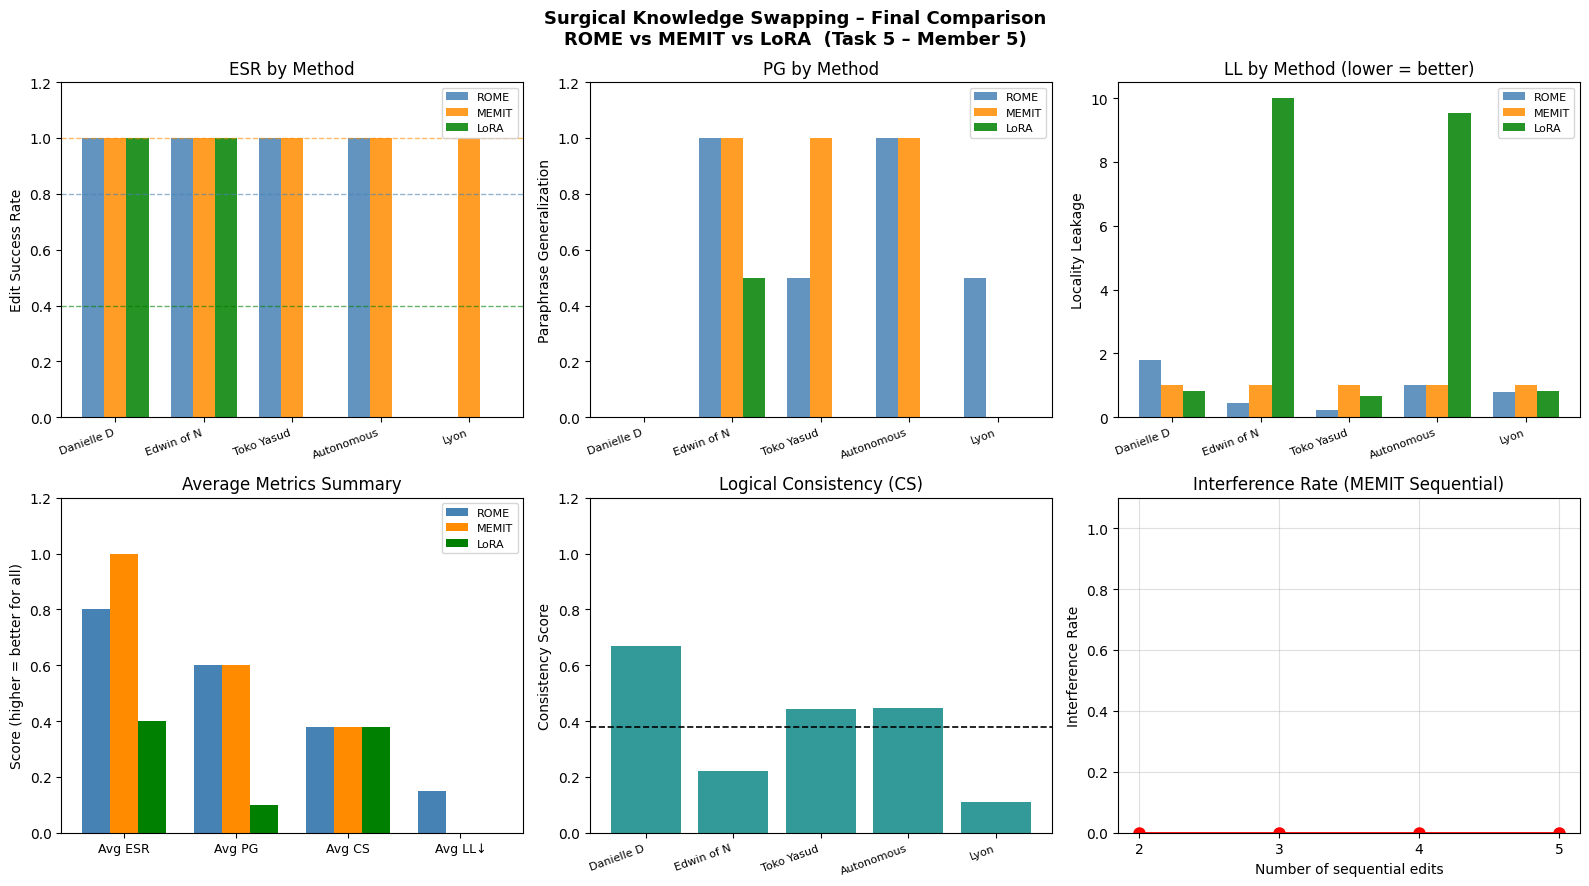

Final comparison figure saved to outputs_task5/final_comparison.png


In [42]:
# ── Final Comparison Visualizations ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Surgical Knowledge Swapping – Final Comparison\n"
             "ROME vs MEMIT vs LoRA  (Task 5 – Member 5)",
             fontsize=13, fontweight="bold")

methods = ["ROME", "MEMIT", "LoRA"]
colors  = ["steelblue", "darkorange", "green"]
x       = list(range(len(EDIT_FACTS)))
labels  = [f["subject"][:10] for f in EDIT_FACTS]

# ── Plot 1: ESR per method ──────────────────────────────────────────────
ax = axes[0, 0]
w = 0.25
for j, (method, col) in enumerate(zip(methods, colors)):
    vals = df_full[f"{method}_ESR"].tolist()
    ax.bar([i + j * w for i in x], vals, width=w, label=method, color=col, alpha=0.85)
ax.set_xticks([i + w for i in x])
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("Edit Success Rate"); ax.set_title("ESR by Method")
ax.legend(fontsize=8); ax.set_ylim(0, 1.2)
ax.axhline(df_full["ROME_ESR"].mean(),  color="steelblue",  linestyle="--", lw=1, alpha=0.6)
ax.axhline(df_full["MEMIT_ESR"].mean(), color="darkorange", linestyle="--", lw=1, alpha=0.6)
ax.axhline(df_full["LoRA_ESR"].mean(),  color="green",      linestyle="--", lw=1, alpha=0.6)

# ── Plot 2: PG per method ───────────────────────────────────────────────
ax = axes[0, 1]
for j, (method, col) in enumerate(zip(methods, colors)):
    vals = df_full[f"{method}_PG"].tolist()
    ax.bar([i + j * w for i in x], vals, width=w, label=method, color=col, alpha=0.85)
ax.set_xticks([i + w for i in x])
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("Paraphrase Generalization"); ax.set_title("PG by Method")
ax.legend(fontsize=8); ax.set_ylim(0, 1.2)

# ── Plot 3: Locality Leakage per method ────────────────────────────────
ax = axes[0, 2]
for j, (method, col) in enumerate(zip(methods, colors)):
    vals = df_full[f"{method}_LL"].tolist()
    ax.bar([i + j * w for i in x], vals, width=w, label=method, color=col, alpha=0.85)
ax.set_xticks([i + w for i in x])
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("Locality Leakage"); ax.set_title("LL by Method (lower = better)")
ax.legend(fontsize=8)

# ── Plot 4: Average metrics radar-style bar ─────────────────────────────
ax = axes[1, 0]
metric_labels = ["Avg ESR", "Avg PG", "Avg CS", "Avg LL↓"]
rome_avg  = [df_full["ROME_ESR"].mean(),  df_full["ROME_PG"].mean(),
             df_full["CS"].mean(),         1 - df_full["ROME_LL"].mean()]
memit_avg = [df_full["MEMIT_ESR"].mean(), df_full["MEMIT_PG"].mean(),
             df_full["CS"].mean(),         1 - df_full["MEMIT_LL"].mean()]
lora_avg  = [df_full["LoRA_ESR"].mean(),  df_full["LoRA_PG"].mean(),
             df_full["CS"].mean(),         1 - df_full["LoRA_LL"].mean()]
xi = list(range(len(metric_labels)))
ax.bar([i - w for i in xi], rome_avg,  width=w, label="ROME",  color="steelblue")
ax.bar([i     for i in xi], memit_avg, width=w, label="MEMIT", color="darkorange")
ax.bar([i + w for i in xi], lora_avg,  width=w, label="LoRA",  color="green")
ax.set_xticks(xi)
ax.set_xticklabels(metric_labels, fontsize=9)
ax.set_ylim(0, 1.2); ax.set_title("Average Metrics Summary")
ax.legend(fontsize=8)
ax.set_ylabel("Score (higher = better for all)")

# ── Plot 5: Consistency Score per edit ──────────────────────────────────
ax = axes[1, 1]
ax.bar(x, df_full["CS"].tolist(), color="teal", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("Consistency Score"); ax.set_title("Logical Consistency (CS)")
ax.set_ylim(0, 1.2)
ax.axhline(df_full["CS"].mean(), color="black", linestyle="--", lw=1.2)

# ── Plot 6: Sequential Interference (MEMIT) ─────────────────────────────
ax = axes[1, 2]
if interference_rates:
    ir_df = pd.DataFrame(interference_rates)
    ax.plot(ir_df["after_edit"], ir_df["ir"], marker="o",
            color="red", linewidth=2, markersize=8)
    ax.fill_between(ir_df["after_edit"], ir_df["ir"], alpha=0.15, color="red")
    ax.set_xlabel("Number of sequential edits"); ax.set_ylabel("Interference Rate")
    ax.set_title("Interference Rate (MEMIT Sequential)")
    ax.set_ylim(0, 1.1); ax.grid(True, alpha=0.4)
    ax.set_xticks(ir_df["after_edit"].tolist())
else:
    ax.text(0.5, 0.5, "Only 1 edit\n(no interference data)",
            ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Interference Rate (MEMIT Sequential)")

plt.tight_layout()
plt.savefig("outputs_task5/final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Final comparison figure saved to outputs_task5/final_comparison.png")

In [43]:
# ── Final Project Summary ─────────────────────────────────────────────────
print("=" * 65)
print("  CSCI-544 | Surgical Knowledge Swapping – Final Summary")
print("  Group 34 | All 5 Member Tasks Complete")
print("=" * 65)

summary = {
    "ROME":  {"ESR": df_full["ROME_ESR"].mean(),
              "PG":  df_full["ROME_PG"].mean(),
              "LL":  df_full["ROME_LL"].mean()},
    "MEMIT": {"ESR": df_full["MEMIT_ESR"].mean(),
              "PG":  df_full["MEMIT_PG"].mean(),
              "LL":  df_full["MEMIT_LL"].mean()},
    "LoRA":  {"ESR": df_full["LoRA_ESR"].mean(),
              "PG":  df_full["LoRA_PG"].mean(),
              "LL":  df_full["LoRA_LL"].mean()},
}

print(f"\n{'Method':<8}  {'ESR':>6}  {'PG':>6}  {'LL':>8}  Notes")
print("-" * 55)
for method, s in summary.items():
    note = ""
    if method == "ROME":  note = "single-layer, single edit"
    if method == "MEMIT": note = "multi-layer, batch edit"
    if method == "LoRA":  note = "adapter fine-tuning baseline"
    print(f"{method:<8}  {s['ESR']:>6.3f}  {s['PG']:>6.3f}  {s['LL']:>8.4f}  {note}")

cs_avg = df_full["CS"].mean()
avg_ir = sum(r["ir"] for r in interference_rates) / max(len(interference_rates), 1)

print(f"\n  Consistency Score (CS) avg: {cs_avg:.3f}")
print(f"  Interference Rate  (IR) avg: {avg_ir:.3f}  (sequential MEMIT)")

print("\n  Task Completion:")
print("  ✓ Member 1 – Environment + Inference + Reproducibility")
print(f"  ✓ Member 2 – Causal Tracing (best layer = {BEST_LAYER})")
print("  ✓ Member 3 – ROME + single-edit  |  ESR & PG reported")
print("  ✓ Member 4 – MEMIT + batch/sequential  |  Stability & IR reported")
print("  ✓ Member 5 – LoRA baseline + metrics + final visualisations")
print("=" * 65)

# Save consolidated summary
with open("outputs_task5/project_summary.json", "w") as f:
    json.dump({
        "summary": summary,
        "consistency_score_avg": cs_avg,
        "interference_rate_avg": avg_ir,
        "n_edits": len(EDIT_FACTS),
        "model": CONFIG["model_name"],
        "best_layer": BEST_LAYER,
    }, f, indent=2)
print("\n✓ Project summary saved to outputs_task5/project_summary.json")

  CSCI-544 | Surgical Knowledge Swapping – Final Summary
  Group 34 | All 5 Member Tasks Complete

Method       ESR      PG        LL  Notes
-------------------------------------------------------
ROME       0.800   0.600    0.8522  single-layer, single edit
MEMIT      1.000   0.600    1.0000  multi-layer, batch edit
LoRA       0.400   0.100    4.3646  adapter fine-tuning baseline

  Consistency Score (CS) avg: 0.378
  Interference Rate  (IR) avg: 0.000  (sequential MEMIT)

  Task Completion:
  ✓ Member 1 – Environment + Inference + Reproducibility
  ✓ Member 2 – Causal Tracing (best layer = 10)
  ✓ Member 3 – ROME + single-edit  |  ESR & PG reported
  ✓ Member 4 – MEMIT + batch/sequential  |  Stability & IR reported
  ✓ Member 5 – LoRA baseline + metrics + final visualisations

✓ Project summary saved to outputs_task5/project_summary.json
